# **Exploratory Data Analysis**

### *Clinical Trial CTN-0051: Extended-Release Naltroxone vs. Buprenorphine for Opioid Treatment*


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import numpy as np

# ── Load files ────────────────────────────────────────────────────────────────
baseline = pd.read_csv("clean-data/pre-trial.csv")
target   = pd.read_csv("clean-data/retention_tier.csv")

# ── Join on PATID ─────────────────────────────────────────────────────────────
df = baseline.merge(target, on='PATID', how='inner')
print(f"EDA dataframe shape: {df.shape}")

EDA dataframe shape: (554, 41)


In [4]:
# ── Define feature groups ─────────────────────────────────────────────────────
detox_cols = [
    'detox_los',
    'detox_admission_day',
    'detox_discharge_day',
    'last_substance_code',
    'last_route_code',
    'discharge_facility_code',
]
dsm_score_cols = [
    'dsm_opioid_score',
    'dsm_alcohol_score',
    'dsm_stimulant_score',
    'dsm_cannabis_score',
    'dsm_cocaine_score',
    'dsm_sedative_score',
]
dsm_item_cols = [
    'opi_tolerance',          'opi_withdrawal',
    'opi_larger_longer_dose', 'opi_cut_back_unsuccess',
    'opi_time_spent',         'opi_activities_reduced',
    'opi_continued_use_despite_problems',
    'opi_strong_craving',     'opi_hazardous_use',
    'opi_social_problems',    'opi_recurrent_obligat_fail',
]
ase_cols = [
    'education_years',        'occupation_category',
    'has_drivers_licence',    'has_automobile',
    'days_paid_employment_30d','days_any_employment_30d',
    'income_employment_30d',  'income_unemployment_30d',
    'income_welfare_30d',     'income_illegal_30d',
    'n_dependants',
]
all_features = detox_cols + dsm_score_cols + ase_cols

# Keep only columns present in the dataframe
all_features  = [c for c in all_features  if c in df.columns]
detox_cols    = [c for c in detox_cols    if c in df.columns]
dsm_score_cols= [c for c in dsm_score_cols if c in df.columns]
ase_cols      = [c for c in ase_cols      if c in df.columns]

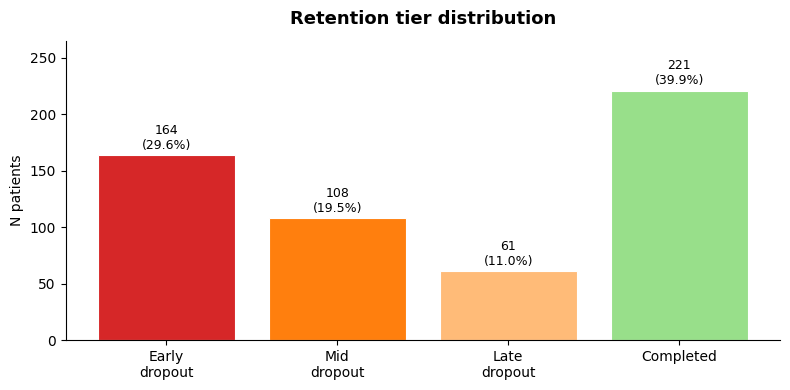

In [5]:
# ── 1. Target distribution ────────────────────────────────────────────────────
tier_labels_short = {
    0: 'Never\nengaged',
    1: 'Early\ndropout',
    2: 'Mid\ndropout',
    3: 'Late\ndropout',
    4: 'Completed',
}
colors = ['#d62728','#ff7f0e','#ffbb78','#98df8a','#2ca02c']

fig, ax = plt.subplots(figsize=(8, 4))
vc = df['retention_tier'].value_counts().sort_index()
bars = ax.bar(
    [tier_labels_short[i] for i in vc.index],
    vc.values,
    color=colors,
    edgecolor='white',
    linewidth=0.8,
)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Retention tier distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('N patients')
ax.set_ylim(0, vc.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig('eda_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

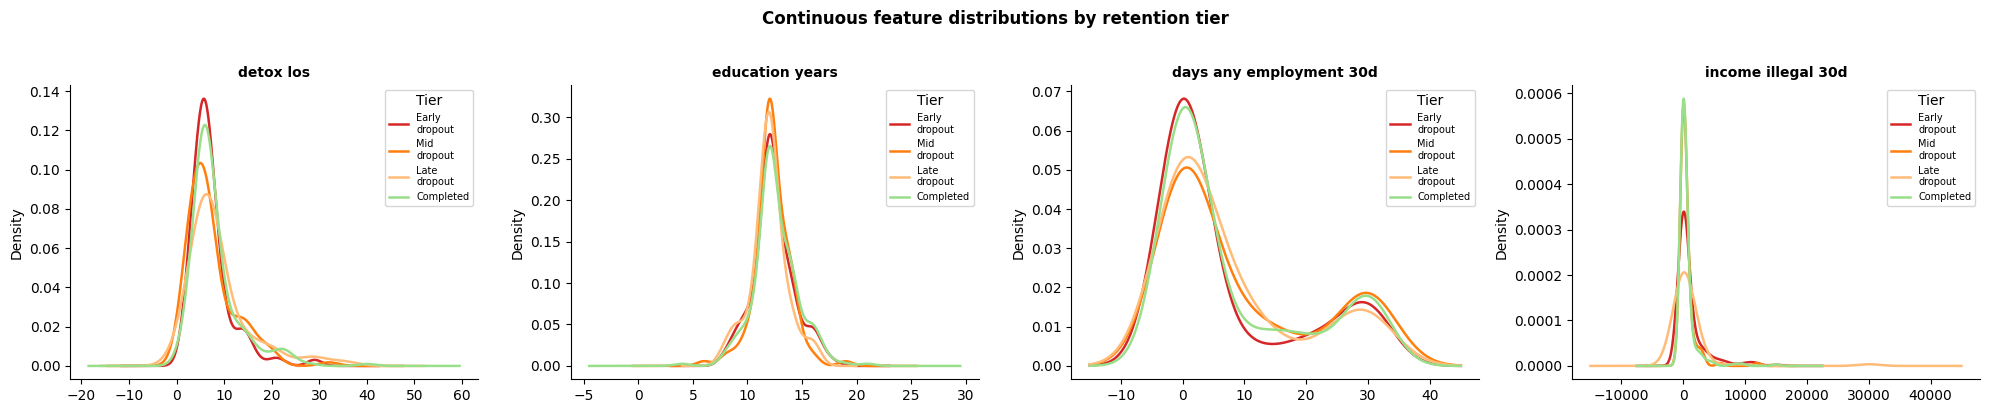

In [6]:
# ── 2. Continuous feature distributions by tier ───────────────────────────────
cont_cols = ['detox_los', 'education_years',
             'days_any_employment_30d', 'income_illegal_30d']
cont_cols = [c for c in cont_cols if c in df.columns]

fig, axes = plt.subplots(1, len(cont_cols), figsize=(5 * len(cont_cols), 4))
if len(cont_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cont_cols):
    for tier, color in zip(sorted(df['retention_tier'].unique()), colors):
        vals = df[df['retention_tier'] == tier][col].dropna()
        vals.plot.kde(ax=ax, label=tier_labels_short[tier],
                      color=color, linewidth=1.8)
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7, title='Tier')
    sns.despine(ax=ax)

plt.suptitle('Continuous feature distributions by retention tier',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_continuous_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

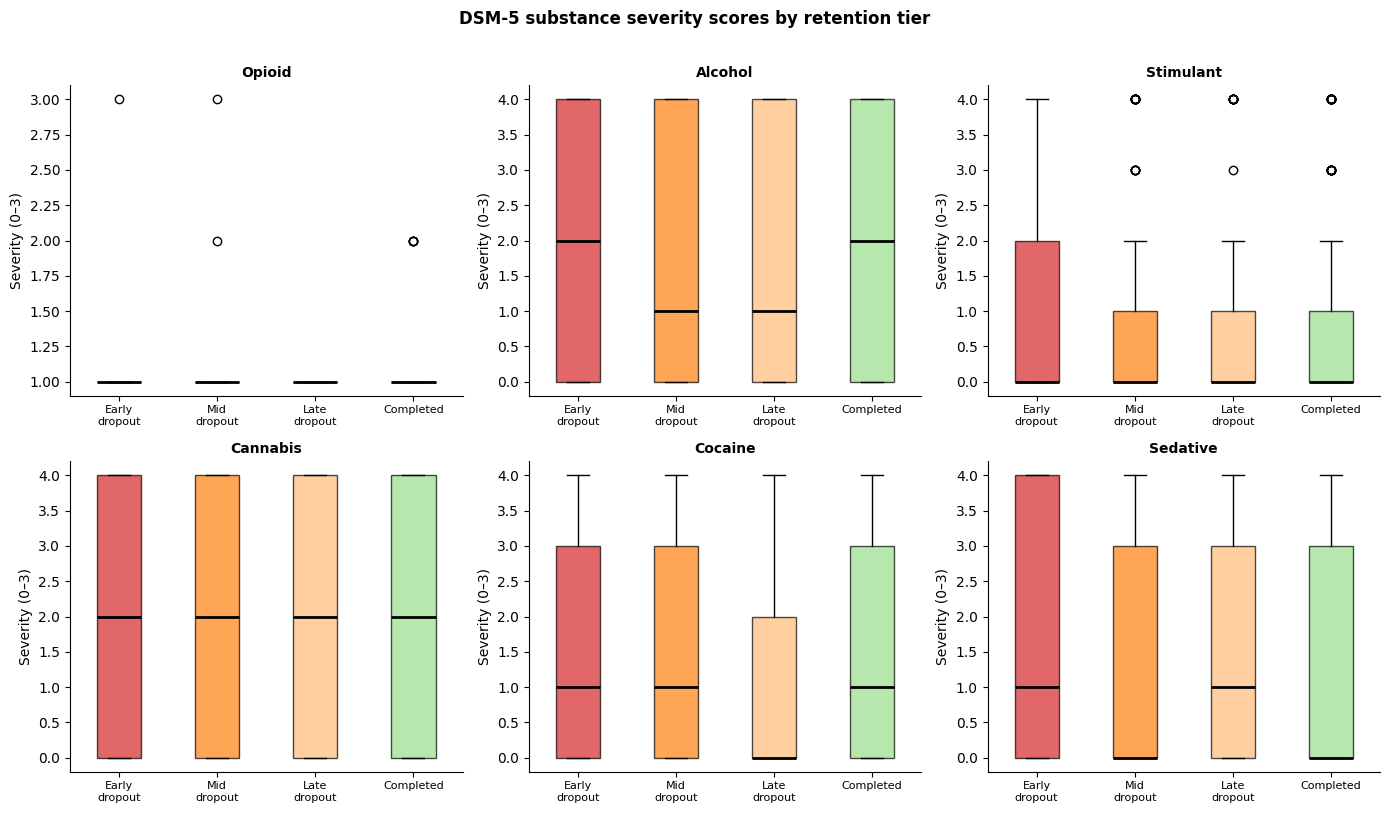

In [7]:
# ── 3. DSM substance scores by tier (boxplots) ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, dsm_score_cols):
    data = [df[df['retention_tier'] == t][col].dropna().values
            for t in sorted(df['retention_tier'].unique())]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([tier_labels_short[t]
                        for t in sorted(df['retention_tier'].unique())],
                       fontsize=8)
    ax.set_title(col.replace('dsm_','').replace('_score','').title(),
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Severity (0–3)')
    sns.despine(ax=ax)

plt.suptitle('DSM-5 substance severity scores by retention tier',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_dsm_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

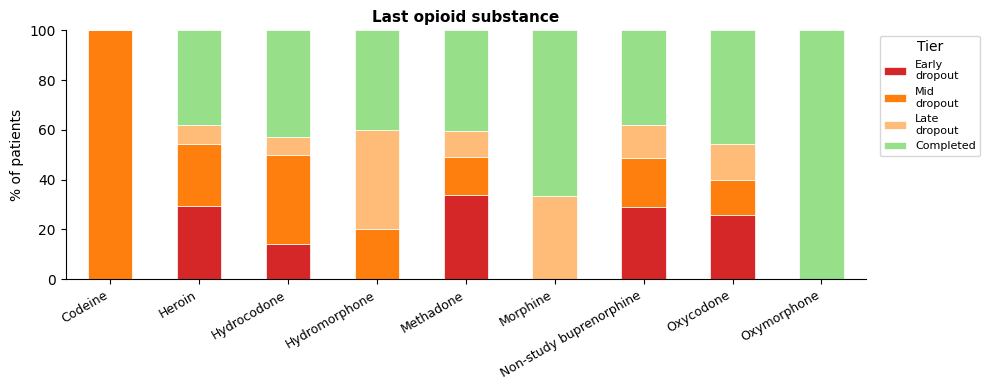

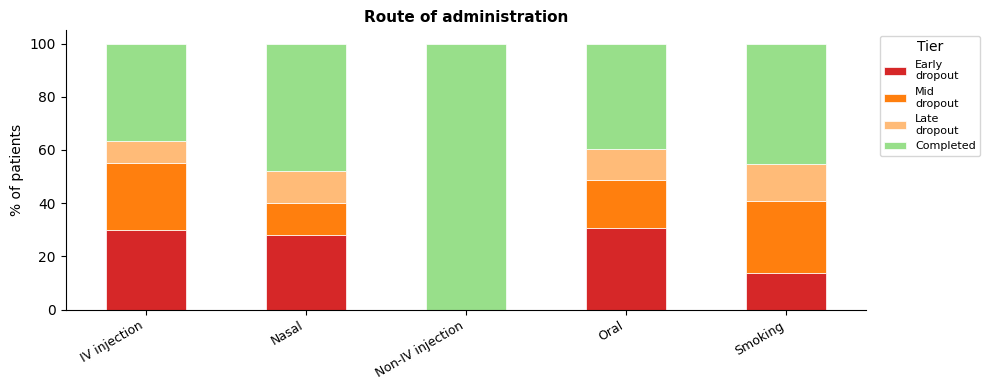

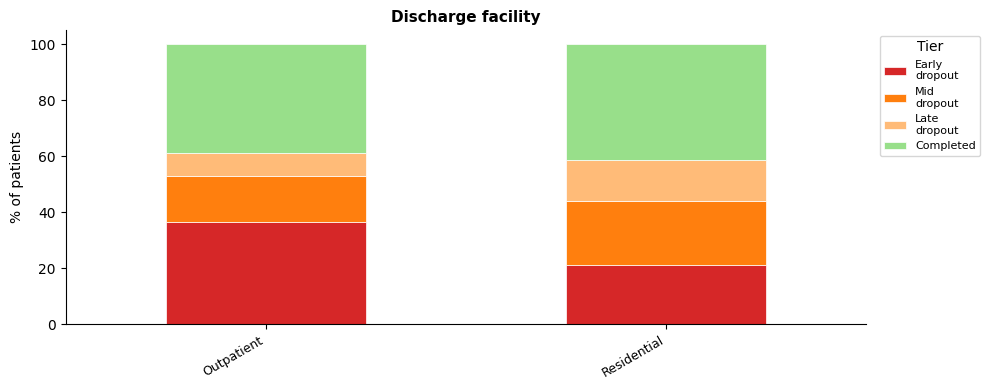

In [11]:
# ── 4. Categorical features by tier (stacked bar) ────────────────────────────
cat_cols = {
    'last_substance_label'    : 'Last opioid substance',
    'last_route_label'        : 'Route of administration',
    'discharge_facility_label': 'Discharge facility',
}

for col, title in cat_cols.items():
    if col not in df.columns:
        continue
    ct = pd.crosstab(df[col], df['retention_tier'], normalize='index') * 100
    ct.columns = [tier_labels_short[c] for c in ct.columns]

    fig, ax = plt.subplots(figsize=(10, 4))
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=colors[:len(ct.columns)], edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% of patients')
    ax.set_xlabel('')
    ax.legend(title='Tier', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=30, ha='right', fontsize=9)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'eda_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

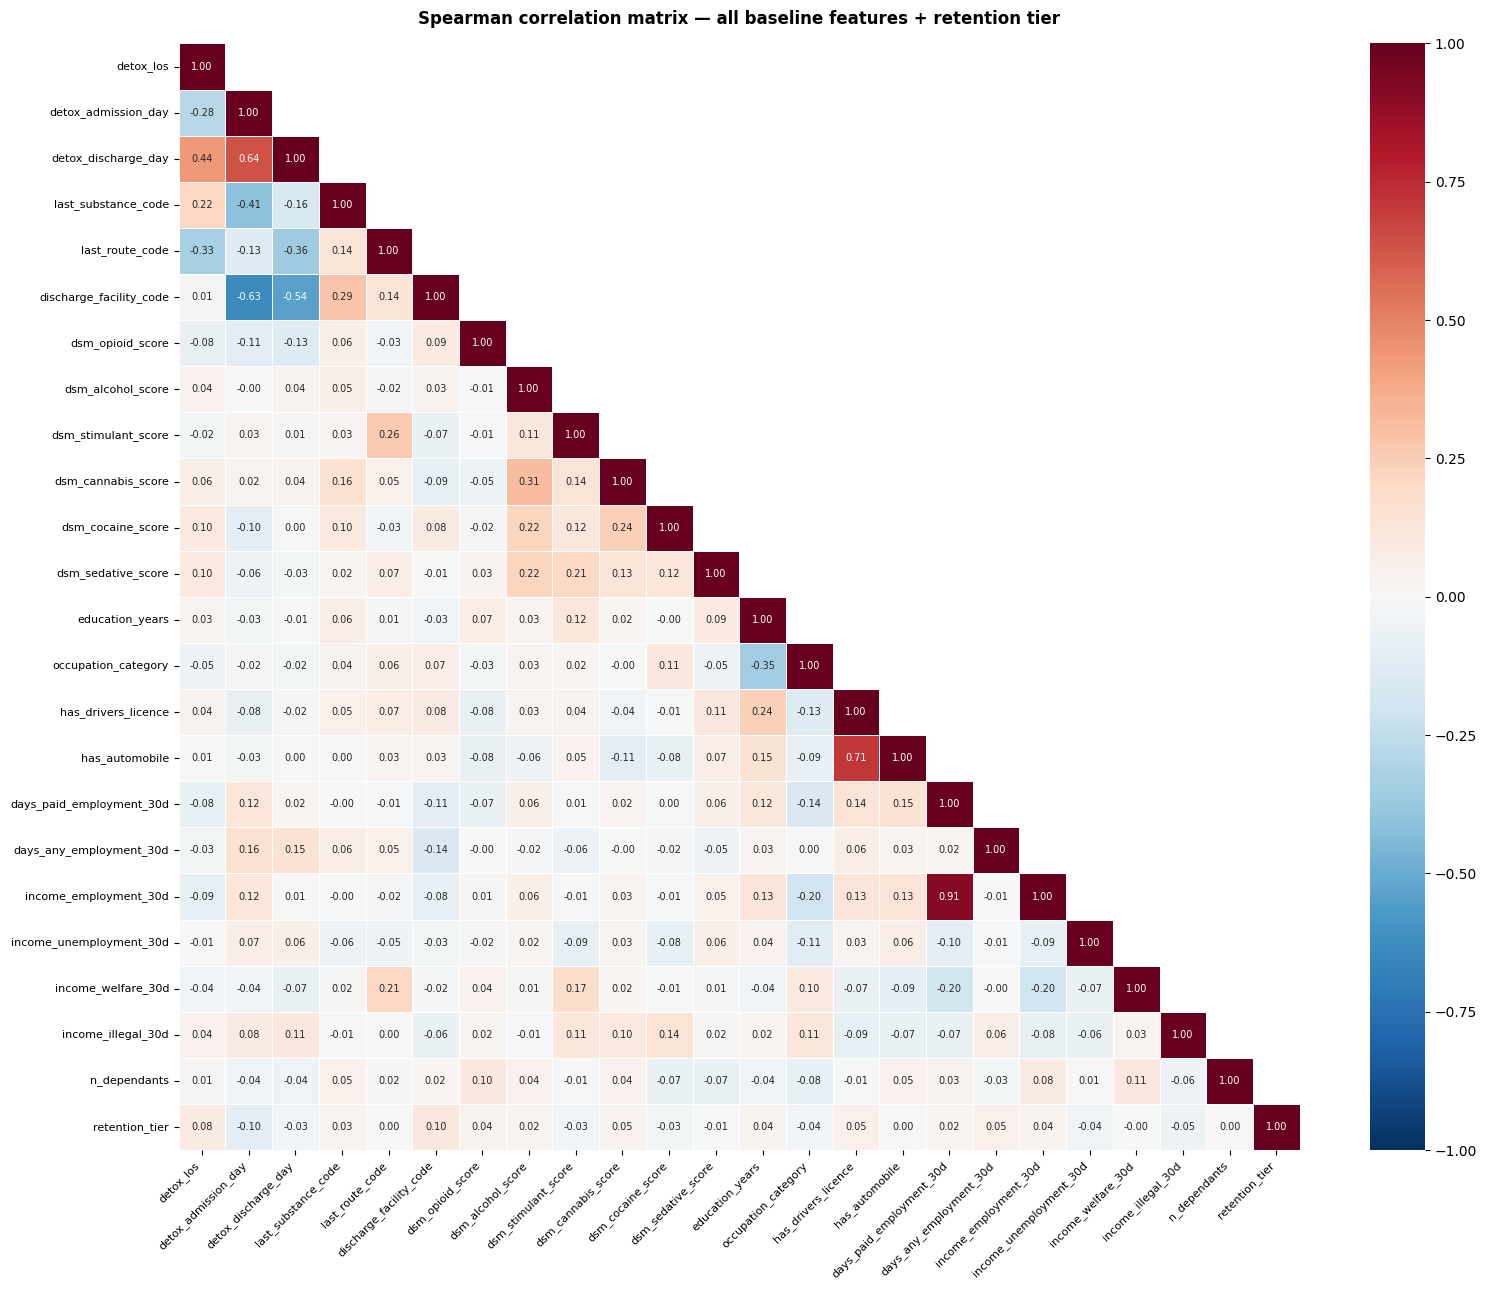

In [12]:
# ── 5. Correlation heatmap with retention tier ────────────────────────────────
# Use Spearman rank correlation (robust to non-normality and ordinal variables)

corr_df = df[all_features + ['retention_tier']].copy()

# Encode remaining string categoricals if any
for col in corr_df.select_dtypes(include='object').columns:
    corr_df[col] = pd.factorize(corr_df[col])[0]

spearman_corr = corr_df.corr(method='spearman')

# ── Full feature-feature heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 7},
    ax=ax,
)
ax.set_title('Spearman correlation matrix — all baseline features + retention tier',
             fontsize=12, fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('eda_full_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

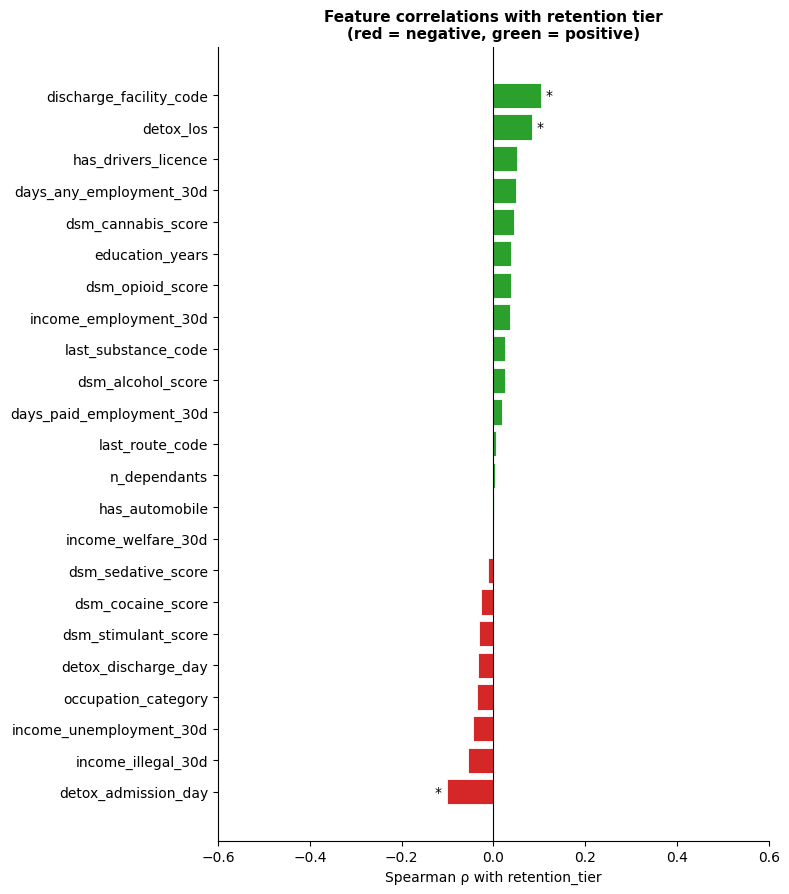


Top 5 positive correlations with retention tier:
dsm_cannabis_score         0.046
days_any_employment_30d    0.050
has_drivers_licence        0.051
detox_los                  0.084
discharge_facility_code    0.104

Top 5 negative correlations with retention tier:
detox_admission_day       -0.102
income_illegal_30d        -0.055
income_unemployment_30d   -0.044
occupation_category       -0.035
detox_discharge_day       -0.034


In [13]:
# ── 6. Correlations with retention tier only (sorted bar chart) ───────────────
tier_corr = (
    spearman_corr['retention_tier']
    .drop('retention_tier')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, len(tier_corr) * 0.35 + 1))
bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in tier_corr.values]
ax.barh(tier_corr.index, tier_corr.values, color=bar_colors,
        edgecolor='white', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ with retention_tier', fontsize=10)
ax.set_title('Feature correlations with retention tier\n(red = negative, green = positive)',
             fontsize=11, fontweight='bold')

# Significance markers (p < 0.05)
for i, col in enumerate(tier_corr.index):
    rho, p = stats.spearmanr(
        df[col].fillna(df[col].median()),
        df['retention_tier']
    )
    if p < 0.05:
        ax.text(tier_corr[col] + 0.01 if tier_corr[col] >= 0 else tier_corr[col] - 0.01,
                i, '*', ha='left' if tier_corr[col] >= 0 else 'right',
                va='center', fontsize=10, color='black')

ax.set_xlim(-0.6, 0.6)
sns.despine()
plt.tight_layout()
plt.savefig('eda_tier_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 positive correlations with retention tier:")
print(tier_corr.tail(5).round(3).to_string())
print("\nTop 5 negative correlations with retention tier:")
print(tier_corr.head(5).round(3).to_string())